In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

print("--- AI Environment Setup ---")
print(f"TensorFlow Version: {tf.__version__}")

# Check if Colab GPU is active
physical_devices = tf.config.list_physical_devices('GPU')
if len(physical_devices) > 0:
    print(f"[+] SUCCESS! GPU is active and ready: {physical_devices}")
else:
    print("[-] WARNING: No GPU detected. Make sure to turn it on in the Runtime settings!")

--- AI Environment Setup ---
TensorFlow Version: 2.19.0
[+] SUCCESS! GPU is active and ready: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from tensorflow.keras.layers import Input, Conv2D, concatenate
from tensorflow.keras.models import Model

# We'll use smaller image patches (64x64 pixels) to train the AI efficiently
IMAGE_SIZE = 64

def build_hiding_network():
    print("Building the AI Hiding Network...")

    # 1. The Inputs (What we feed the AI)
    # The Cover Image (3 color channels: RGB)
    cover_input = Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3), name="Cover_Image")
    # The Secret Data (We'll format our encrypted text as a 1-channel image layer)
    secret_input = Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 1), name="Secret_Data")

    # 2. The Preparation Layer
    # This helps the AI format the secret data before merging it
    prep_conv1 = Conv2D(50, (3, 3), activation='relu', padding='same')(secret_input)
    prep_conv2 = Conv2D(50, (3, 3), activation='relu', padding='same')(prep_conv1)

    # 3. The Hiding Layer
    # We smash the cover image and the prepared secret data together
    combined_data = concatenate([cover_input, prep_conv2])

    # These layers act like a complex filter, deciding which pixels to tweak
    hide_conv1 = Conv2D(50, (3, 3), activation='relu', padding='same')(combined_data)
    hide_conv2 = Conv2D(50, (3, 3), activation='relu', padding='same')(hide_conv1)

    # 4. The Output Layer
    # The final output is the Stego Image (back to 3 color channels)
    stego_output = Conv2D(3, (3, 3), activation='sigmoid', padding='same', name="Stego_Image")(hide_conv2)

    # Bundle it all into a formal AI Model
    model = Model(inputs=[cover_input, secret_input], outputs=stego_output, name="Steganography_Encoder")
    return model

# Create the model and print its blueprint
hiding_model = build_hiding_network()
hiding_model.summary()

Building the AI Hiding Network...


Model: "Steganography_Encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Secret_Data         │ (None, 64, 64, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │        500 │ Secret_Data[0][0] │
│                     │ 50)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Cover_Image         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │     22,550 │ conv2d[0][0]      │
│                     │ 50)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ Cover_Image[0][0… │
│ (Concatenate)       │ 53)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     23,900 │ concatenate[0][0] │
│                     │ 50)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     22,550 │ conv2d_2[0][0]    │
│                     │ 50)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Stego_Image         │ (None, 64, 64, 3) │      1,353 │ conv2d_3[0][0]    │
│ (Conv2D)            │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 70,853 (276.77 KB)

 Trainable params: 70,853 (276.77 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def build_reveal_network():
    print("Building the AI Reveal Network...")

    # 1. The Input (The Stego Image we just created)
    stego_input = Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3), name="Stego_Input")

    # 2. The Extraction Layers
    # The AI scans the image to separate the secret data from the cover image noise
    reveal_conv1 = Conv2D(50, (3, 3), activation='relu', padding='same')(stego_input)
    reveal_conv2 = Conv2D(50, (3, 3), activation='relu', padding='same')(reveal_conv1)
    reveal_conv3 = Conv2D(50, (3, 3), activation='relu', padding='same')(reveal_conv2)

    # 3. The Output Layer
    # Reconstructs the hidden 1-channel secret data (values between 0 and 1)
    secret_output = Conv2D(1, (3, 3), activation='sigmoid', padding='same', name="Extracted_Secret")(reveal_conv3)

    # Bundle it into a Model
    model = Model(inputs=stego_input, outputs=secret_output, name="Steganography_Decoder")
    return model

# Create the reveal model and print its blueprint
reveal_model = build_reveal_network()
reveal_model.summary()

Building the AI Reveal Network...


Model: "Steganography_Decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Stego_Input (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 50)     │         1,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 50)     │        22,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 50)     │        22,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Extracted_Secret (Conv2D)       │ (None, 64, 64, 1)      │           451 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,951 (183.40 KB)

 Trainable params: 46,951 (183.40 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def build_full_autoencoder(encoder, decoder):
    print("Connecting the networks into a single AI pipeline...")

    # 1. The Starting Line (Inputs)
    cover_input = Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3), name="Original_Cover")
    secret_input = Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 1), name="Original_Secret")

    # 2. Step One: Hide the data
    stego_image = encoder([cover_input, secret_input])

    # 3. Step Two: Reveal the data
    extracted_secret = decoder(stego_image)

    # 4. Bundle it into one giant network
    full_model = Model(inputs=[cover_input, secret_input],
                       outputs=[stego_image, extracted_secret],
                       name="Full_Steganography_Pipeline")

    # 5. The Rules of the Game (Compilation)
    # 'adam' is the engine that updates the math.
    # 'mse' (Mean Squared Error) calculates how badly the AI messed up.
    # loss_weights=[1.0, 1.0] means we care equally about the image looking normal AND extracting the right data.
    full_model.compile(optimizer='adam', loss=['mse', 'mse'], loss_weights=[1.0, 1.0])

    return full_model

# Create the full pipeline and view the summary
full_pipeline = build_full_autoencoder(hiding_model, reveal_model)
full_pipeline.summary()

Connecting the networks into a single AI pipeline...


Model: "Full_Steganography_Pipeline"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Original_Cover      │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Original_Secret     │ (None, 64, 64, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Steganography_Enco… │ (None, 64, 64, 3) │     70,853 │ Original_Cover[0… │
│ (Functional)        │                   │            │ Original_Secret[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Steganography_Deco… │ (None, 64, 64, 1) │     46,951 │ Steganography_En… │
│ (Functional)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 117,804 (460.17 KB)

 Trainable params: 117,804 (460.17 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import numpy as np

print("--- Preparing the Simulation ---")

# Let's generate 1,000 fake images to train the AI
NUM_SAMPLES = 1000
# (This matches the IMAGE_SIZE = 64 we set earlier)

# 1. Create Fake Cover Images (Random color noise, values between 0 and 1)
dummy_covers = np.random.rand(NUM_SAMPLES, IMAGE_SIZE, IMAGE_SIZE, 3).astype('float32')

# 2. Create Fake Secret Data (Random grayscale noise, values between 0 and 1)
dummy_secrets = np.random.rand(NUM_SAMPLES, IMAGE_SIZE, IMAGE_SIZE, 1).astype('float32')

print(f"[+] Successfully generated {NUM_SAMPLES} fake cover images and secret payloads!")

# 3. Let the Game Begin! (Training the Model)
print("\n--- Starting AI Training (5 Epochs) ---")
print("Watch the 'loss' numbers. If they go down, the AI is getting smarter!\n")

# We use the pipeline we built.
# x = What we feed it (Cover + Secret)
# y = What we want it to output (The exact same Cover + Secret)
history = full_pipeline.fit(
    x=[dummy_covers, dummy_secrets],
    y=[dummy_covers, dummy_secrets],
    batch_size=32,       # It learns by looking at 32 images at a time
    epochs=5,            # It will play the game 5 times through the whole dataset
    validation_split=0.2 # It sets aside 20% of the data to test itself at the end of each round
)

print("\n[+] SUCCESS! The test training run is complete.")

--- Preparing the Simulation ---
[+] Successfully generated 1000 fake cover images and secret payloads!

--- Starting AI Training (5 Epochs) ---
Watch the 'loss' numbers. If they go down, the AI is getting smarter!

Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 114ms/step - Steganography_Decoder_loss: 0.0837 - Steganography_Encoder_loss: 0.0742 - loss: 0.1579 - val_Steganography_Decoder_loss: 0.0832 - val_Steganography_Encoder_loss: 0.0406 - val_loss: 0.1237
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - Steganography_Decoder_loss: 0.0829 - Steganography_Encoder_loss: 0.0316 - loss: 0.1146 - val_Steganography_Decoder_loss: 0.0779 - val_Steganography_Encoder_loss: 0.0148 - val_loss: 0.0926
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - Steganography_Decoder_loss: 0.0667 - Steganography_Encoder_loss: 0.0183 - loss: 0.0850 - val_Steganography_Decoder_loss: 0.0373 - val_Steganography_Encoder_loss: 0.0263 - val_loss: 0.0635
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - Steganogra

--- Generating Visual Results ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 606ms/step


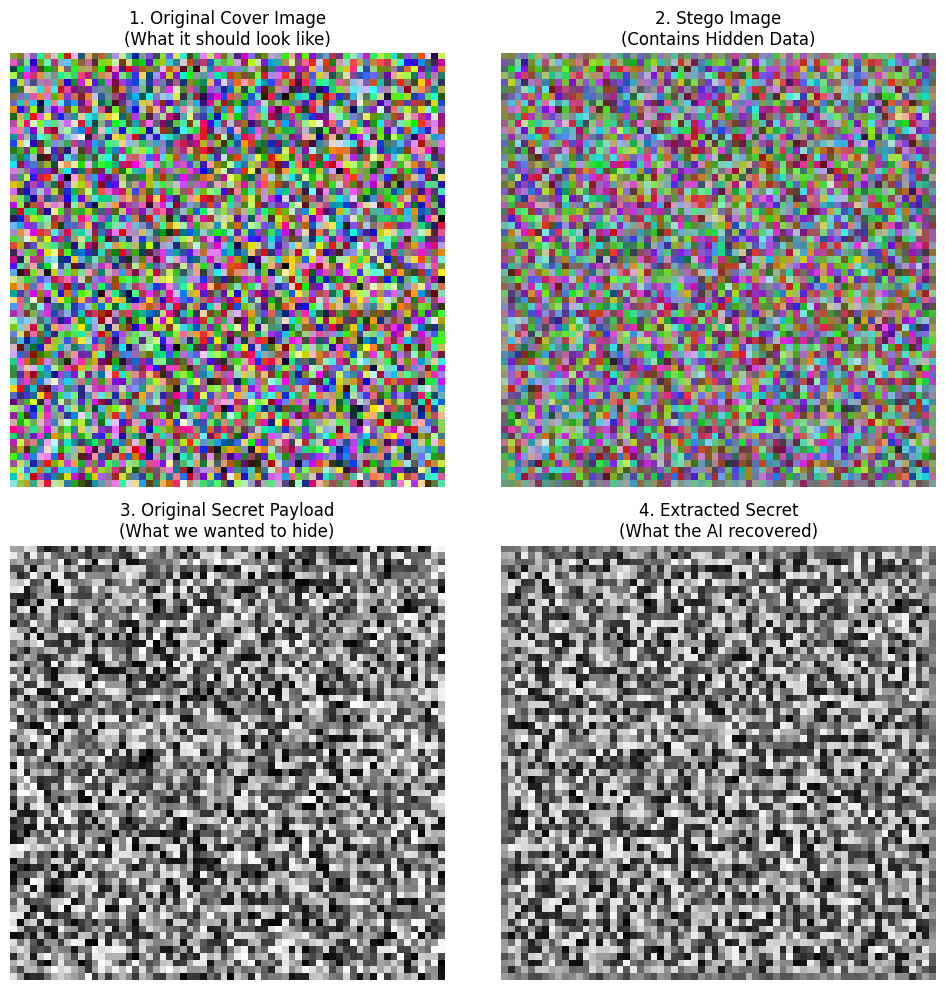

In [ ]:
import matplotlib.pyplot as plt

print("--- Generating Visual Results ---")

# 1. Pick the very first image from our dummy dataset to test
test_cover = dummy_covers[0:1]
test_secret = dummy_secrets[0:1]

# 2. Ask the AI to hide and reveal the data
stego_output, extracted_secret = full_pipeline.predict([test_cover, test_secret])

# 3. Set up a 2x2 grid to display the images
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# Top Left: Original Cover
axes[0, 0].imshow(test_cover[0])
axes[0, 0].set_title("1. Original Cover Image\n(What it should look like)")
axes[0, 0].axis('off')

# Top Right: Stego Image
axes[0, 1].imshow(stego_output[0])
axes[0, 1].set_title("2. Stego Image\n(Contains Hidden Data)")
axes[0, 1].axis('off')

# Bottom Left: Original Secret
axes[1, 0].imshow(test_secret[0, :, :, 0], cmap='gray')
axes[1, 0].set_title("3. Original Secret Payload\n(What we wanted to hide)")
axes[1, 0].axis('off')

# Bottom Right: Extracted Secret
axes[1, 1].imshow(extracted_secret[0, :, :, 0], cmap='gray')
axes[1, 1].set_title("4. Extracted Secret\n(What the AI recovered)")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

--- 1. Upload Your Real Cover Image ---


Saving cover.jpg to cover (1).jpg

[+] Preparing Secret Payload: 'CLASSIFIED DATA: Final Year Project Integrity Test!'

--- AI is hiding the data... ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step


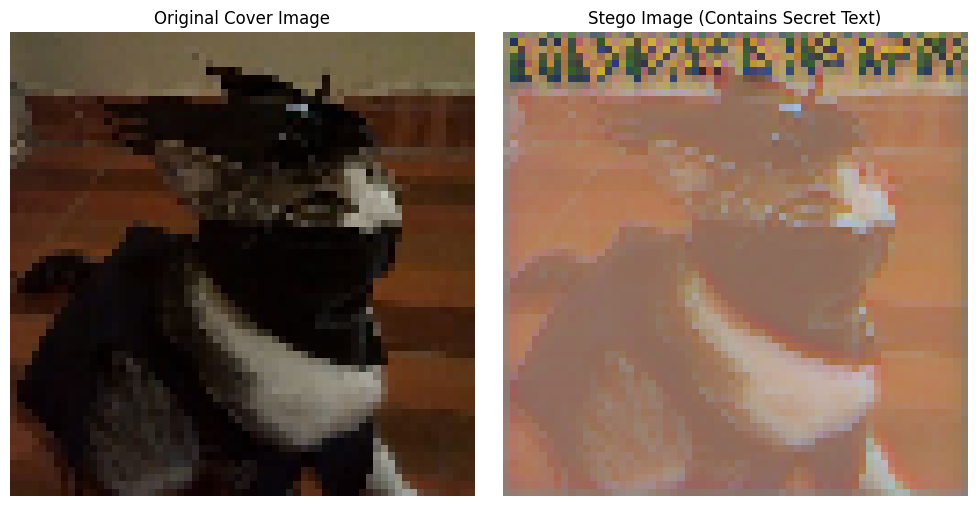


[+] Success! Visual comparison complete.


In [ ]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("--- 1. Upload Your Real Cover Image ---")
# This will trigger a "Choose Files" button in Colab
uploaded = files.upload()

# Get the exact filename you uploaded
filename = list(uploaded.keys())[0]

# --- 2. Process the Cover Image ---
# Read the image, fix the colors, and resize it to fit the AI's 64x64 brain
img = cv2.imread(filename)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
cover_resized = cv2.resize(img, (64, 64))
# Normalize the pixel values to be between 0 and 1
cover_normalized = cover_resized.astype('float32') / 255.0
# Add the batch dimension so the AI understands it: Shape becomes (1, 64, 64, 3)
cover_input = np.expand_dims(cover_normalized, axis=0)

# --- 3. Process the Secret Text Payload ---
secret_text = "CLASSIFIED DATA: Final Year Project Integrity Test!"
print(f"\n[+] Preparing Secret Payload: '{secret_text}'")

# Convert the text into binary (0s and 1s)
binary_secret = ''.join(format(ord(char), '08b') for char in secret_text)

# Create an empty 64x64 grid and fill it with our binary text data
secret_grid = np.zeros((64 * 64), dtype='float32')
for i, bit in enumerate(binary_secret):
    if i < len(secret_grid):
        secret_grid[i] = float(bit)

# Reshape back to 64x64 and add dimensions for the AI: Shape becomes (1, 64, 64, 1)
secret_grid = secret_grid.reshape((64, 64))
secret_input = np.expand_dims(secret_grid, axis=(0, -1))

# --- 4. Run the AI (The Magic) ---
print("\n--- AI is hiding the data... ---")
# The Hiding Network generates the Stego Image
stego_image = hiding_model.predict([cover_input, secret_input])

# --- 5. Visualize the Results ---
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(cover_normalized)
axes[0].set_title("Original Cover Image")
axes[0].axis('off')

# Ensure the output is safely clipped between 0 and 1 for displaying
axes[1].imshow(np.clip(stego_image[0], 0.0, 1.0))
axes[1].set_title("Stego Image (Contains Secret Text)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

print("\n[+] Success! Visual comparison complete.")